This notebook will extract the ship's location from output of `EXTAER` and then compare vertical profiles of `EXTAER` from ACI_OPT_2 and NO_BLOW_SNOW to see how switching off blowing snow affects the model overestimation of extinction. Likewise for AOD maps.

In [1]:
import pandas as pd
import xarray as xr
import datetime as dt
import numpy as np
import utils
import wrfpp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import glob
import re

# Read model output

In [2]:
mosaic_nav = xr.open_dataset("/mnt/data/mosaic/nav/mosaic_coords_2020-04.nc")
mosaic_nav = mosaic_nav.assign_coords({"day": ("time", [T.dt.day for T in mosaic_nav.time])})

simulations = {
    "NO_BLOW_SNOW": {
        "microphysics": "Thompson",
        "pollution_state": "polluted",
    },
    "NO_BLOW_SNOW_CLEAN": {
        "microphysics": "Thompson",
        "pollution_state": "clean",
    },
    "ACI_OPT_2": {
        "microphysics": "Thompson",
        "pollution_state": "polluted",
    },
    "ACI_OPT_2_NO_ANTHRO_NO_FIRES": {
        "microphysics": "Thompson",
        "pollution_state": "clean",
    }
}

vars_to_load = [
    "EXTAER2",
    "EXTAER3",
    "AOD2D_OUT",
    "PH",
    "PHB"
]

wrfout = []

for sim,meta in simulations.items():
    print(sim)
    sim_data = []
    for v in vars_to_load:
        print(v)
        var = []
        fname = glob.glob(f"/mnt/data/model_output/{sim}/{v}_2020-04-*.nc")
        if not fname:
            continue
        with xr.open_mfdataset(fname).set_index(Time="XTIME") as wrfout_grid:
            mosaic_coords = mosaic_nav.sel(time=wrfout_grid.Time)

            for i in range(len(wrfout_grid.Time)):
                wrfout_ts = wrfout_grid.isel(Time=i).compute()
                wrfout_ts = wrfout_ts.expand_dims({
                    "simulation": [sim]
                })
                wrfout_ts = wrfout_ts.assign_coords({
                    "pollution_state": ("simulation",[meta["pollution_state"]]),
                    "longitude": (["south_north","west_east"],wrfout_grid.XLONG.isel(Time=0).values),
                    "latitude": (["south_north","west_east"],wrfout_grid.XLAT.isel(Time=0).values),
                })
                mosaic_ts = mosaic_coords.isel(Time=i)
                var.append(wrfout_ts.wrf.value_around_point(
                    lon=mosaic_ts.Longitude,
                    lat=mosaic_ts.Latitude,
                    method="mean"
                ))
        sim_data.append(xr.concat(var, dim="Time"))
    wrfout.append(xr.merge(sim_data))

wrfout = xr.concat(wrfout, dim="simulation")



NO_BLOW_SNOW
EXTAER2
EXTAER3
AOD2D_OUT
PH
PHB


/tmp/ipykernel_891/1605138702.py:62: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  wrfout.append(xr.merge(sim_data))


NO_BLOW_SNOW_CLEAN
EXTAER2
EXTAER3
AOD2D_OUT
PH
PHB


/tmp/ipykernel_891/1605138702.py:62: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  wrfout.append(xr.merge(sim_data))


ACI_OPT_2
EXTAER2
EXTAER3
AOD2D_OUT
PH
PHB
ACI_OPT_2_NO_ANTHRO_NO_FIRES
EXTAER2
EXTAER3
AOD2D_OUT


/tmp/ipykernel_891/1605138702.py:62: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Time' ('Time',) The recommendation is to set join explicitly for this case.
  wrfout.append(xr.merge(sim_data))
/tmp/ipykernel_891/1605138702.py:62: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  wrfout.append(xr.merge(sim_data))


PH
PHB


/tmp/ipykernel_891/1605138702.py:64: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Time' ('Time',) The recommendation is to set join explicitly for this case.
  wrfout = xr.concat(wrfout, dim="simulation")


In [3]:
aod = []
for sim, meta in simulations.items():
    print(sim)
    fname = glob.glob(f"/mnt/data/model_output/{sim}/AOD2D_OUT_2020-04-*.nc")
    ds = xr.open_mfdataset(fname).set_index(Time="XTIME")
    ds = ds.expand_dims({"simulation":[sim]})
    ds = ds.assign_coords({
        "day": ("Time",[T.dt.day for T in ds.Time]),
        "pollution_state": ("simulation",[meta["pollution_state"]]),
        "microphysics": ("simulation",[meta["microphysics"]]),
        "longitude": (["south_north","west_east"],ds.XLONG.isel(Time=0).values),
        "latitude": (["south_north","west_east"],ds.XLAT.isel(Time=0).values),
    })
    aod.append(ds)
aod = xr.concat(aod, dim="simulation")


NO_BLOW_SNOW
NO_BLOW_SNOW_CLEAN
ACI_OPT_2
ACI_OPT_2_NO_ANTHRO_NO_FIRES


/tmp/ipykernel_891/209718192.py:15: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Time' ('Time',) The recommendation is to set join explicitly for this case.
  aod = xr.concat(aod, dim="simulation")
/tmp/ipykernel_891/209718192.py:15: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  aod = xr.concat(aod, dim="simulation")


In [4]:
altitude = wrfout.sel(simulation="NO_BLOW_SNOW").wrf.altitude_asl_c
wrfout["altitude"] = altitude.transpose("Time","bottom_top")


# Compare to measured profiles

### Read measurement data
DOI : https://doi.org/10.1594/PANGAEA.935539 

In [5]:
# define lidar ratio as used in Ansmann et al 2023
# they use this to calculate extinction coefficient from backscatter coefficient
L = 55 # sr


In [6]:
def extract_times(filename):
    # matches: ---YYYYMMDD_HHMM-HHMM-...
    m = re.search(r'(\d{8})_(\d{4})-(\d{4})-', filename)
    if not m:
        raise ValueError(f"Filename doesn't match expected pattern: {filename}")
    
    date_str, start_str, end_str = m.groups()
    
    start_dt = dt.datetime.strptime(date_str + start_str, "%Y%m%d%H%M")
    end_dt = dt.datetime.strptime(date_str + end_str, "%Y%m%d%H%M")
    
    return start_dt, end_dt

def read_lidar_profile(filename, L=L):
    start, end = extract_times(filename)
    profile = pd.read_csv(
        filename,
        sep="\t",
        header=0,           # skip the original header line
        na_values=["NaN", "nan", ""],
        engine="python",
        encoding="latin-1",
    )
    beta532 = xr.DataArray(
        profile["Beta532 (Mm^-1 sr^-1):"].values,
        dims="height",
        coords={"height": profile.index}
    )
    alpha532 = xr.DataArray(
        profile["alpha532 (Mm^-1 sr^-1):"].values,
        dims="height",
        coords={"height": profile.index}
    )
    return start, end, beta532, alpha532


In [7]:
files = np.sort(glob.glob("/mnt/data/mosaic/polly-lidar/*61smooth.txt"))
start, end, backscatter, ext = [], [], [], []
for f in files:
    profile = read_lidar_profile(f)
    start.append(profile[0])
    end.append(profile[1])
    backscatter.append(profile[2])
    ext.append(profile[3])

profiles = xr.Dataset(
    coords={
        "start_time": ("time", start),
        "end_time": ("time", end),
        "height": ("height", backscatter[0].height.values),
    },
    data_vars={
        "backscatter": (["time","height"], backscatter),
        "extinction": (["time","height"], ext),
    }
)

ext_derived = profiles.backscatter * L


In [8]:
def interp_1d(height, var, height_new):
    return np.interp(height_new, height, var)

def interp_zdim(ds, da_height_new):
    vars_to_interp = [v for v in ds.data_vars if v not in ["altitude","PH","PHB"]]
    ds_interp = xr.Dataset()
    da_height_old = ds["altitude"].drop_attrs()
    for var in vars_to_interp:
        if "bottom_top" not in ds[var].dims:
            print(f"skipping {var} with no height coordinate")
            continue
        ds_interp[var] = xr.apply_ufunc(
            interp_1d,
            da_height_old,         # first arg: height profile
            ds[var],              # second arg: variable profile
            da_height_new,        # third arg: target heights
            input_core_dims=[["bottom_top"],["bottom_top"],["bottom_top"]],
            output_core_dims=[["bottom_top"]],
            vectorize=True,           # loop automatically over (sim, time)
            dask="parallelized",      # works with dask arrays
            keep_attrs="no_conflicts"
        )
    # add new height coordinate
    ds_interp = ds_interp.assign_coords({
        'height': (['bottom_top'], da_height_new.data)
    })
    return ds_interp

In [9]:
ext_profiles = interp_zdim(wrfout, wrfout.altitude.mean("Time", keep_attrs=False))



skipping AOD2D_OUT with no height coordinate


In [10]:
ls = {
    "polluted": "solid",
    "clean": "dashed"
}

c = {
    "ACI_OPT_2": "tab:red",
    "ACI_OPT_2_NO_ANTHRO_NO_FIRES": "tab:red",
    "NO_BLOW_SNOW": "tab:purple",
    "NO_BLOW_SNOW_CLEAN": "tab:purple",
}

Text(0.5, 0.95, '2020-04-17 04:30')

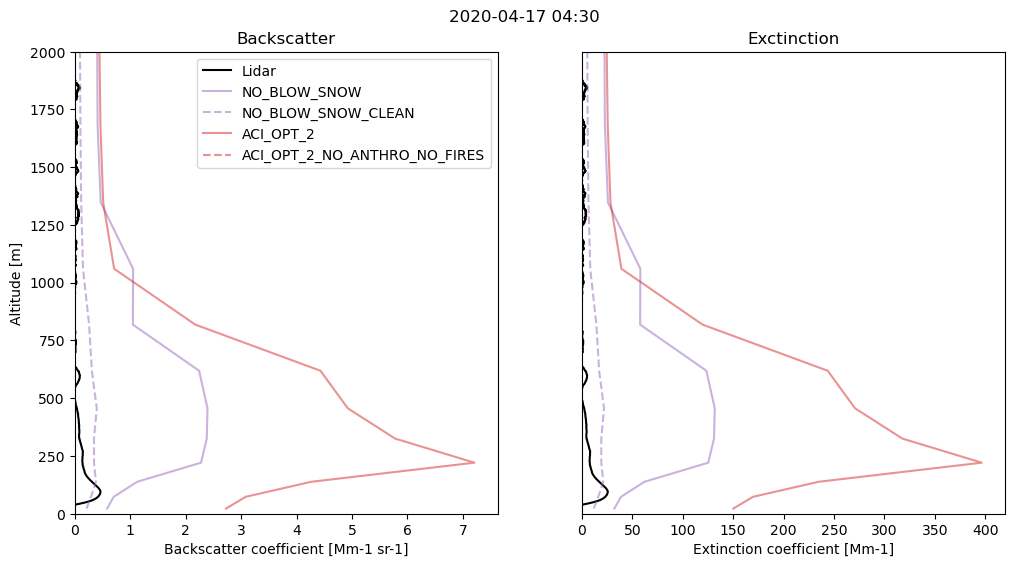

In [21]:
# plot single profile to send round as an example

i = 6

fig, axes = plt.subplots(1, 2, figsize=(12,6))
time = profiles.start_time.values[i]
profile = profiles.isel(time=i)
ext_profile = ext_derived.isel(time=i)
axes[0].plot(
    profile.backscatter,
    profile.height,
    color="k",
    label="Lidar"
)
axes[1].plot(
    ext_profile,
    ext_profile.height,
    color="k",
)
for sim,meta in simulations.items():
    model_profile_extcof = ext_profiles.EXTAER2.sel(Time=time, method="nearest").sel(simulation=sim)
    axes[0].plot(
        1000*model_profile_extcof/L,
        model_profile_extcof.height,
        color=c[sim],
        label=sim,
        ls=ls[meta["pollution_state"]],
        alpha=0.5,
    )
    axes[1].plot(
        1000*model_profile_extcof,
        model_profile_extcof.height,
        color=c[sim],
        ls=ls[meta["pollution_state"]],
        alpha=0.5,
    )

for ax in axes:
    ax.set_ylim(0, 2000)
    ax.set_xlim(left=0)

axes[0].legend()
axes[1].set_yticks([])
axes[0].set_title("Backscatter")
axes[1].set_title("Exctinction")
axes[0].set_xlabel("Backscatter coefficient [Mm-1 sr-1]")
axes[0].set_ylabel("Altitude [m]")
axes[1].set_xlabel("Extinction coefficient [Mm-1]")
fig.suptitle(dt.datetime.strftime(pd.to_datetime(time), "%Y-%m-%d %H:%M"), y=0.95)

Text(0.5, 0.95, '2020-04-11 06:00')

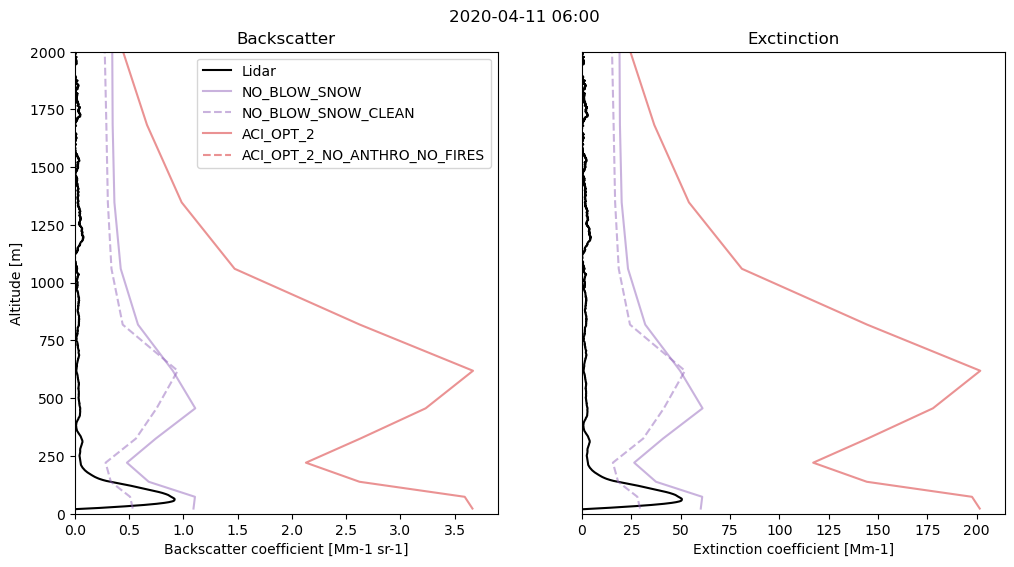

In [23]:
# plot single profile to send round as an example

i = 3

fig, axes = plt.subplots(1, 2, figsize=(12,6))
time = profiles.start_time.values[i]
profile = profiles.isel(time=i)
ext_profile = ext_derived.isel(time=i)
axes[0].plot(
    profile.backscatter,
    profile.height,
    color="k",
    label="Lidar"
)
axes[1].plot(
    ext_profile,
    ext_profile.height,
    color="k",
)
for sim, meta in simulations.items():
    model_profile_extcof = ext_profiles.EXTAER2.sel(Time=time, method="nearest").sel(simulation=sim)
    axes[0].plot(
        1000*model_profile_extcof/L,
        model_profile_extcof.height,
        color=c[sim],
        ls=ls[meta["pollution_state"]],
        label=sim,
        alpha=0.5
    )
    axes[1].plot(
        1000*model_profile_extcof,
        model_profile_extcof.height,
        color=c[sim],
        ls=ls[meta["pollution_state"]],
        alpha=0.5
)

for ax in axes:
    ax.set_ylim(0, 2000)
    ax.set_xlim(left=0)

axes[0].legend()
axes[1].set_yticks([])
axes[0].set_title("Backscatter")
axes[1].set_title("Exctinction")
axes[0].set_xlabel("Backscatter coefficient [Mm-1 sr-1]")
axes[0].set_ylabel("Altitude [m]")
axes[1].set_xlabel("Extinction coefficient [Mm-1]")
fig.suptitle(dt.datetime.strftime(pd.to_datetime(time), "%Y-%m-%d %H:%M"), y=0.95)

Text(0.5, 0.95, '2020-04-11 21:00')

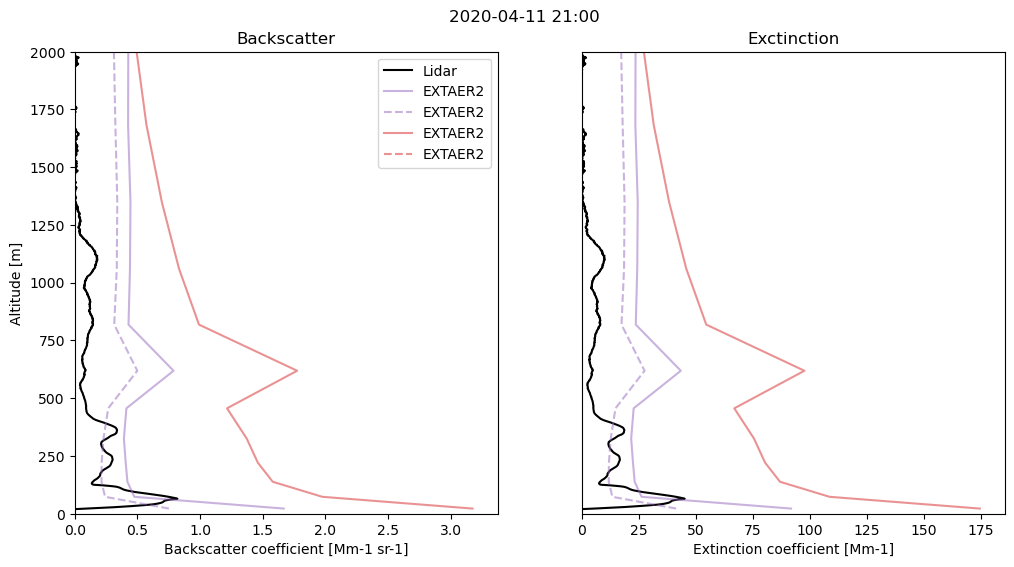

In [25]:
# plot single profile to send round as an example

i = 4

fig, axes = plt.subplots(1, 2, figsize=(12,6))
time = profiles.start_time.values[i]
profile = profiles.isel(time=i)
ext_profile = ext_derived.isel(time=i)
axes[0].plot(
    profile.backscatter,
    profile.height,
    color="k",
    label="Lidar"
)
axes[1].plot(
    ext_profile,
    ext_profile.height,
    color="k",
)
for sim, meta in simulations.items():
    model_profile_extcof = ext_profiles.EXTAER2.sel(Time=time, method="nearest").sel(simulation=sim)
    axes[0].plot(
        1000*model_profile_extcof/L,
        model_profile_extcof.height,
        color=c[sim],
        ls=ls[meta["pollution_state"]],
        alpha=0.5,
        label="EXTAER2",
    )
    axes[1].plot(
        1000*model_profile_extcof,
        model_profile_extcof.height,
        color=c[sim],
        ls=ls[meta["pollution_state"]],
        alpha=0.5,
    )

for ax in axes:
    ax.set_ylim(0, 2000)
    ax.set_xlim(left=0)

axes[0].legend()
axes[1].set_yticks([])
axes[0].set_title("Backscatter")
axes[1].set_title("Exctinction")
axes[0].set_xlabel("Backscatter coefficient [Mm-1 sr-1]")
axes[0].set_ylabel("Altitude [m]")
axes[1].set_xlabel("Extinction coefficient [Mm-1]")
fig.suptitle(dt.datetime.strftime(pd.to_datetime(time), "%Y-%m-%d %H:%M"), y=0.95)

# Calculate AOD from extinction profiles

In [11]:
lidar_dz = profiles.height.diff("height")
aod_lidar = (1e-6*ext_derived.isel(height=slice(1,None))*lidar_dz).sum("height")

Text(0.5, 1.0, 'Whole column AOD')

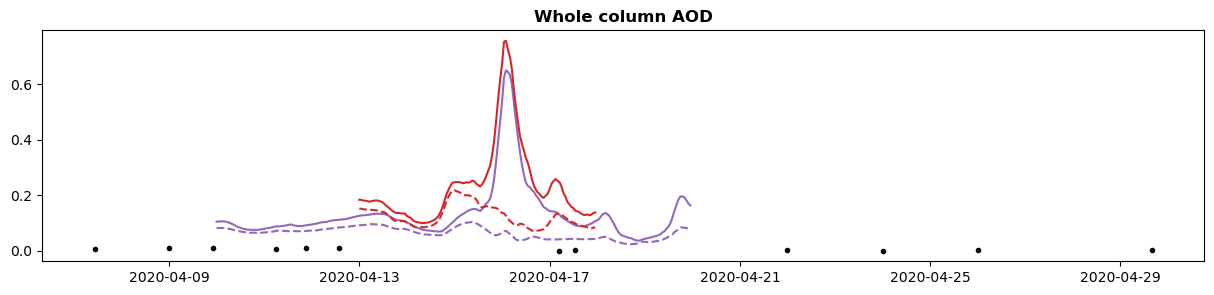

In [64]:
fig = plt.figure(figsize=(15,3))
plt.plot(ext_derived.start_time, aod_lidar, "k.")
for sim, meta in simulations.items():
    plt.plot(
        wrfout.Time,
        wrfout.AOD2D_OUT.sel(simulation=sim),
        color=c[sim],
        ls=ls[meta["pollution_state"]]
    )

plt.title("Whole column AOD", weight="bold")

In [15]:
# integrate extinction over just lower atmosphere
# because maybe lidar doesn't penetrate whole column

box_dz = (
    wrfout.wrf.altitude_asl[:].isel(bottom_top_stag=slice(1, None))
    - wrfout.wrf.altitude_asl[:].isel(bottom_top_stag=slice(None, -1))
).sel(simulation="NO_BLOW_SNOW")
box_dz = box_dz.rename({"bottom_top_stag": "bottom_top"})

lid = 2500
aod_lower_atmos = (1e-3*wrfout.EXTAER2*box_dz).where(wrfout.altitude<=lid).sum("bottom_top", min_count=1)
aod_all_column = (1e-3*wrfout.EXTAER2*box_dz).sum("bottom_top", min_count=1)


Text(0, 0.5, 'AOD')

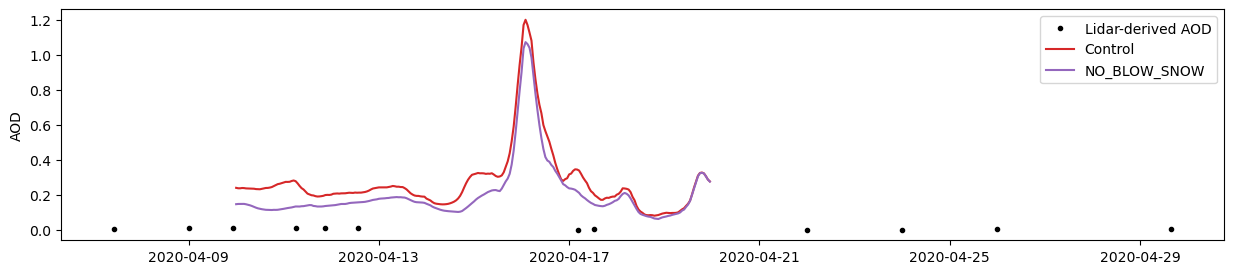

In [25]:
fig = plt.figure(figsize=(15,3))
plt.plot(ext_derived.start_time, aod_lidar, "k.", label="Lidar-derived AOD")

sim = "ACI_OPT_2"

plt.plot(
    wrfout.Time,
    aod_all_column.sel(simulation=sim),
    color=c[sim],
    ls="solid",
    label=f"Control"
)

sim = "NO_BLOW_SNOW"
plt.plot(
    wrfout.Time,
    aod_all_column.sel(simulation=sim),
    color=c[sim],
    ls="solid",
    label=f"{sim}"
)

# plt.xlim(aod_all_column.Time.values[0], aod_all_column.Time.values[-1])

plt.legend()
plt.ylabel("AOD")
# plt.title(f"AOD calculated over only {lid/1000} km", weight="bold")

Text(0.5, 1.0, 'AOD calculated over only 3.0 km')

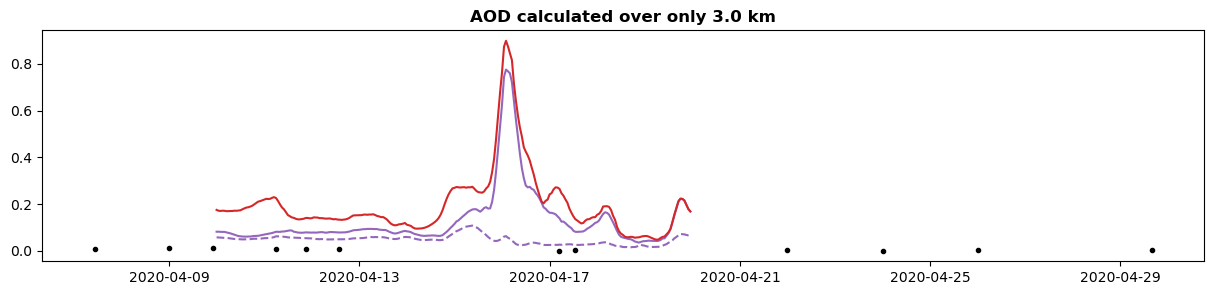

In [63]:
fig = plt.figure(figsize=(15,3))
plt.plot(ext_derived.start_time, aod_lidar, "k.")
for sim, meta in simulations.items():
    plt.plot(
        wrfout.Time,
        aod_lower_atmos.sel(simulation=sim),
        color=c[sim],
        ls=ls[meta["pollution_state"]]
    )

plt.title(f"AOD calculated over only {lid/1000} km", weight="bold")

# Daily AOD maps

Text(0.0, 1.2, 'Thompson')

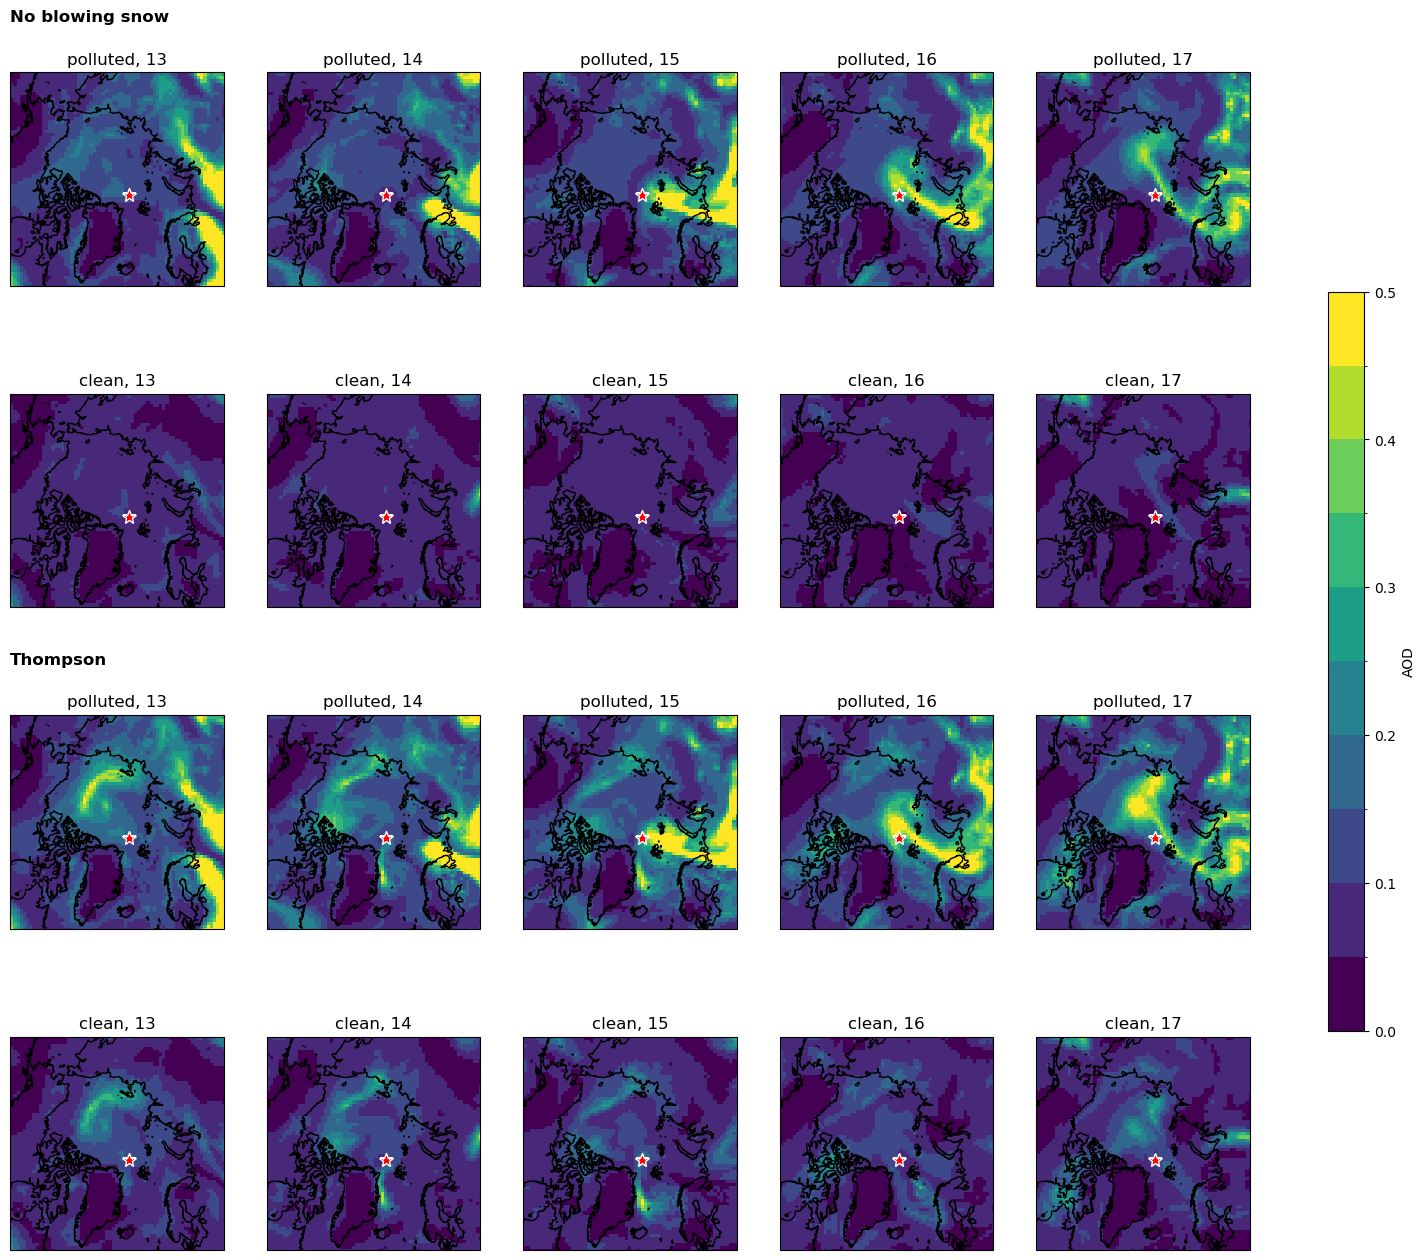

In [66]:
aod_daily = aod.groupby(aod.Time.dt.day).mean()
aod_daily = aod_daily.sel(day=np.arange(13,18))

bounds = np.arange(0, 0.55, 0.05)
norm = matplotlib.colors.BoundaryNorm(boundaries=bounds, ncolors=256)

fig, axes = plt.subplots(
    4, len(aod_daily.day),
    figsize=(20,16),
    subplot_kw=dict(projection=ccrs.NorthPolarStereo(central_longitude=-25))
)

for ax in axes.flatten():
    ax.coastlines()
    ax.set_extent([-180,180,60,90], crs=ccrs.PlateCarree())

for s in range(len(aod_daily.simulation)):
    for i in range(len(aod_daily.day)):
        ax = axes[s,i]
        day = aod_daily.day.values[i]
        plot = ax.pcolormesh(
            aod_daily.longitude,
            aod_daily.latitude,
            aod_daily.isel(simulation=s, day=i).AOD2D_OUT,
            # vmin=0, vmax=0.5,
            norm=norm,
            transform=ccrs.PlateCarree()
        )
        ax.plot(
            mosaic_nav.mean("time").Longitude,
            mosaic_nav.mean("time").Latitude,
            marker="*",
            ms=10,
            color="red",
            mec="white",
            transform=ccrs.PlateCarree()
        )
        ax.set_title(f"{aod_daily.pollution_state.values[s]}, {day}")

plt.colorbar(plot, label="AOD", ax=axes, shrink=0.6)

axes[0,0].set_title("No blowing snow",loc="left",weight="bold",y=1.2)
axes[2,0].set_title("Thompson",loc="left",weight="bold",y=1.2)
